In [1]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize

In [2]:
import sys
import os

# Add project root (210226) to Python path
sys.path.append(os.path.abspath("../../../../"))

from utils.prepare_data import prepare_data

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [4]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [5]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [6]:
dataset_path = '../../../../dataset/Dataset_TehHijau.csv'
feature_cols = [
        "MQ3", 
        "TGS822", 
        "TGS2602", 
        "MQ5", 
        "MQ138", 
        "TGS2620", 
        "TGS813", 
        "TGS2600", 
        "TGS2611", 
        "TGS2603",
        "Humidity",
        "Celsius",
    ]
target_cols = "Kategori"

quantum_kernel_types = [
    # 'full', 
    'linear', 
    # 'circular', 
    # 'pauli_x', 
    # 'pauli_y', 
    # 'pauli_z'
]
kernel_types = [
    'linear', 
    # 'poly', 
    # 'rbf', 
    # 'sigmoid'
]

In [7]:
import pandas as pd
data = pd.read_csv(dataset_path)
data.head(10)

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Chop_ID,Sampling_ID,Aroma,Taste,Color,Appearance,Dreg,Kategori,Standar Kualitas,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
0,90.0,43.0,46.0,133.0,97.0,46.0,552.0,289.0,546.0,371.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
1,90.0,42.0,47.0,133.0,96.0,47.0,551.0,290.0,547.0,371.0,46.5,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
2,89.0,42.0,47.0,133.0,97.0,45.0,553.0,291.0,547.0,369.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.483046,-0.872872,-1.238095,807.0,41.9,41,43,0.737865,0.139942,-0.960433,377.0,46.8,46,48,0.788811,0.343622,-1.153061,421.0,132.5,132,133.0,0.527046,0.0,-2.0,1192.5,96.1,95,97,0.737865,-0.139942,-0.960433,865.0,45.7,45,47,0.674949,0.365675,-0.705532,411.0,551.6,550,553,0.843274,-0.328125,-0.335937,4964.5,289.8,289.0,291,0.788811,0.343622,-1.153061,2609.0,546.5,545,548,0.849837,0.0,-0.485207,4918.5,370.2,369,371,0.788811,-0.343622,-1.153061,3331.0,46.43,46.3,46.5,0.067495,-0.365675,-0.705532,417.95,38.81,38.7,38.9,0.08756,-0.18843,-1.52615,349.3,2.9,2.9,2.9,4.681111e-16,26.1,36,36,36,0,324,3.2,3.2,3.2,4.681111e-16,28.8,2.8,2.8,2.8,4.681111e-16,25.2,3.2,3.2,3.2,4.681111e-16,28.8
3,89.0,41.0,47.0,133.0,96.0,45.0,552.0,290.0,546.0,370.0,46.4,38.9,TR612,TR612_1,2.9,36,3.2,2.8,3.2,D,Baik,89.7,89.0,90,0.4

In [8]:
data.describe()

,MQ3,TGS822,TGS2602,MQ5,MQ138,TGS2620,TGS813,TGS2600,TGS2611,TGS2603,Humidity,Celsius,Aroma,Taste,Color,Appearance,Dreg,MQ3_mean,MQ3_min,MQ3_max,MQ3_std,MQ3_skew,MQ3_kurtosis,MQ3_auc,TGS822_mean,TGS822_min,TGS822_max,TGS822_std,TGS822_skew,TGS822_kurtosis,TGS822_auc,TGS2602_mean,TGS2602_min,TGS2602_max,TGS2602_std,TGS2602_skew,TGS2602_kurtosis,TGS2602_auc,MQ5_mean,MQ5_min,MQ5_max,MQ5_std,MQ5_skew,MQ5_kurtosis,MQ5_auc,MQ138_mean,MQ138_min,MQ138_max,MQ138_std,MQ138_skew,MQ138_kurtosis,MQ138_auc,TGS2620_mean,TGS2620_min,TGS2620_max,TGS2620_std,TGS2620_skew,TGS2620_kurtosis,TGS2620_auc,TGS813_mean,TGS813_min,TGS813_max,TGS813_std,TGS813_skew,TGS813_kurtosis,TGS813_auc,TGS2600_mean,TGS2600_min,TGS2600_max,TGS2600_std,TGS2600_skew,TGS2600_kurtosis,TGS2600_auc,TGS2611_mean,TGS2611_min,TGS2611_max,TGS2611_std,TGS2611_skew,TGS2611_kurtosis,TGS2611_auc,TGS2603_mean,TGS2603_min,TGS2603_max,TGS2603_std,TGS2603_skew,TGS2603_kurtosis,TGS2603_auc,Humidity_mean,Humidity_min,Humidity_max,Humidity_std,Humidity_skew,Humidity_kurtosis,Humidity_auc,Celsius_mean,Celsius_min,Celsius_max,Celsius_std,Celsius_skew,Celsius_kurtosis,Celsius_auc,Aroma_mean,Aroma_min,Aroma_max,Aroma_std,Aroma_auc,Taste_mean,Taste_min,Taste_max,Taste_std,Taste_auc,Color_mean,Color_min,Color_max,Color_std,Color_auc,Appearance_mean,Appearance_min,Appearance_max,Appearance_std,Appearance_auc,Dreg_mean,Dreg_min,Dreg_max,Dreg_std,Dreg_auc
count,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,1.040900e+04,1.040900e+04,1.040900e+04,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,10409.0,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000,10409.000000,10409.000000,10409.000000,1.040900e+04,10409.000000
mean,89.414833,47.600730,47.936209,98.291575,89.182246,51.548756,533.670093,213.738592,531.124604,330.500336,48.387732,39.656701,2.935143,34.888942,3.035383,3.135306,3.071880,89.401187,88.072610,90.838121,0.983066,0.031130,-0.497871,797.282995,51.381383,46.428283,86.377366,12.767992,0.047886,-0.767730,461.091603,48.923492,46.665674,56.401095,3.417439,0.042129,-0.742829,435.501633,98.319587,97.190220,99.975002,0.977440,0.153864,-0.336209,872.003728,89.167083,87.839082,90.566625,0.975194,0.054069,-0.778237,790.103132,52.047207,50.200692,56.931309,2.411880,0.011063,-0.779548,460.377366,533.585382,530.475646,535.648189,1.716062,-0.230519,-0.613955,4754.938419,215.542657,212.039427,231.564223,6.549817,-0.059306,-0.657508,1919.990364,531.039823,529.310693,532.089442,1.000540,-0.031123,-0.890127,4742.842444,330.447166,328.831396,331.640503,0.980595,0.022313,-0.777011,2953.280046,4.077809e+03,48.175252,4.034278e+04,1.274229e+04,-2.069636e-02,-0.

Text(0.5, 1.0, 'Histogram for the Kategori')

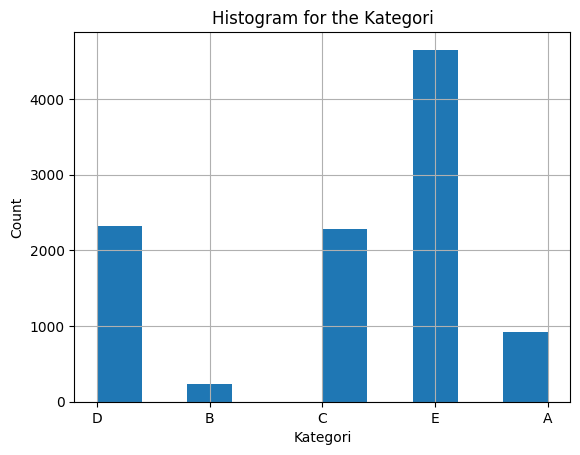

In [9]:
import matplotlib.pyplot as plt
data['Kategori'].hist()
plt.xlabel('Kategori')
plt.ylabel('Count')
plt.title('Histogram for the Kategori')

In [10]:
X = data[feature_cols]
y = data[target_cols]

print(X.shape, y.shape)

(10409, 12) (10409,)


In [11]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [12]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

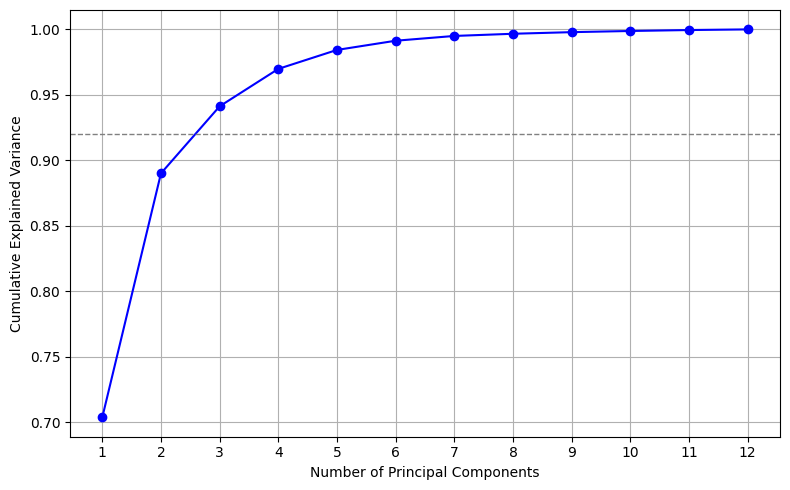

Optimal number of components to retain 92% variance: 3


In [13]:
n_optimal = plot_pca_variance(X, n_components=X.shape[1], threshold=0.92)

### HPO Config

In [14]:
import numpy as np

search_space = {
  'n_estimators': [100, 500, 1000],
  'learning_rate': [0.001, 0.05, 0.1],
  'max_depth': [5, 10, 20],
  'subsample': [0, 0.5, 1],
  'colsample_bytree': [0, 0.5, 1],

  'rate_drop': [0, 0.1, 0.3],
}

param_keys = search_space.keys()
param_vals = search_space.values()

In [ ]:
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
  accuracy_score, f1_score, roc_auc_score,
  average_precision_score, matthews_corrcoef,
  precision_score, recall_score
)

state = 42
n_splits = 5
n_iter = 10

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

search_space_sizes = {k: len(v) for k, v in search_space.items()}
total_configs = np.prod([len(v) for v in param_vals])
total_fits = total_configs * skf.get_n_splits()
space_str = " × ".join([f"{search_space_sizes[k]} {k}" for k in search_space_sizes])

print(f"🔬 Search space: {space_str} =  {total_configs} configs × {skf.get_n_splits()} folds = {total_fits} fits")
print("   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

best_score = -np.inf
best_result = None
results = []
for comb in product(*param_vals):
  params = dict(zip(param_keys, comb))
  tag = " | ".join(f"{k}={v}" for k, v in params.items())
  print(f"\n  ▶ {tag}")

  accs, f1s, rocs, pras, precs, recs= [], [], [], [], [], []
  y_val_all, y_pred_all = [], []
  for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=n_optimal)),
      ('svc', XGBClassifier(
        booster='dart', objective='multi:softprob', random_state=42, **params
      ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)

    y_val_all.extend(y_val)
    y_pred_all.extend(y_pred)

    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc = roc_auc_score(y_val, y_prob, average='weighted', multi_class='ovr')
    pra = average_precision_score(y_val, y_prob, average='weighted')
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')

    accs.append(acc)
    f1s.append(f1)
    rocs.append(roc)
    pras.append(pra)
    precs.append(prec)
    recs.append(rec)

    print(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUROC={roc:.4f} | PRAUC={pra:.4f}")

    results.append({
      "tag": tag,
      **params,
      "fold": fold,
      "accuracy": acc,
      "precision": prec,
      "recall": rec,
      "F1": f1,
      "auroc": roc,
      "prauc": pra,
    })

  # Aggregate
  acc_mean, acc_std = np.mean(accs), np.std(accs)
  prec_mean, prec_std = np.mean(precs), np.std(precs)
  rec_mean, rec_std = np.mean(recs), np.std(recs)
  f1_mean, f1_std = np.mean(f1s), np.std(f1s)
  roc_mean, roc_std = np.mean(rocs), np.std(rocs)
  pra_mean, pra_std = np.mean(pras), np.std(pras)
  mcc = matthews_corrcoef(y_val_all, y_pred_all)

  composite = (roc_mean + pra_mean + acc_mean) / 3

  print(
    f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
    f"Precision:{prec_mean:.4f}±{prec_std:.4f}  |"
    f"Recall:{rec_mean:.4f}±{rec_std:.4f} |"
    f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
    f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
    f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
    f"MCC:{mcc:.4f} | "
    f"Composite:{composite:.4f}"
  )

  if composite > best_score:
    best_score = composite
    best_result = {
        'tag': tag,
        'composite': composite,
        'roc': roc_mean,
        'pra': pra_mean,
        'acc': acc_mean,
        'f1': f1_mean,
        'prec': prec_mean,
        'rec': rec_mean,
        'params': params,
    }

print("\n🏆 Best config :", best_result['tag'])
print(
    f"   Composite   : {best_result['composite']:.4f} "
    f"(AUROC={best_result['roc']:.4f} | "
    f"PRAUC={best_result['pra']:.4f} | "
    f"Acc={best_result['acc']:.4f} |"
    f"Prec={best_result['prec']:.4f} |"
    f"Rec={best_result['rec']:.4f}) |"
)

🔬 Search space: 3 n_estimators × 3 learning_rate × 3 max_depth × 3 subsample × 3 colsample_bytree × 3 rate_drop =  729 configs × 5 folds = 3645 fits
   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3

  ▶ n_estimators=100 | learning_rate=0.001 | max_depth=5 | subsample=0 | colsample_bytree=0 | rate_drop=0
    F1 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.5000 | PRAUC=0.3058
    F2 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.5000 | PRAUC=0.3060
    F3 → Acc=0.4462 | Prec=0.1991 | Rec=0.4462 | F1=0.2753 | AUROC=0.5000 | PRAUC=0.3054
    F4 → Acc=0.4467 | Prec=0.1995 | Rec=0.4467 | F1=0.2758 | AUROC=0.5000 | PRAUC=0.3056
    F5 → Acc=0.4469 | Prec=0.1997 | Rec=0.4469 | F1=0.2761 | AUROC=0.5000 | PRAUC=0.3058
  ✅  Acc:0.4466±0.0002 | Precision:0.1995±0.0002  |Recall:0.4466±0.0002 |F1:0.2758±0.0002 | AUROC:0.5000±0.0000 | PRAUC:0.3057±0.0002 | MCC:0.0000 | Composite:0.4175

  ▶ n_estimators=100 | learning_rate=0.001 | max_depth=5 | subsample=0 | colsam

In [ ]:
import pandas as pd
import os

dirpath = "./results/"
os.makedirs(dirpath, exist_ok=True)

df = pd.DataFrame(results)
filename = dirpath + "xgb_dart.csv"
df.to_csv(filename, index=False)

print(f"✅ Saved: {filename}")